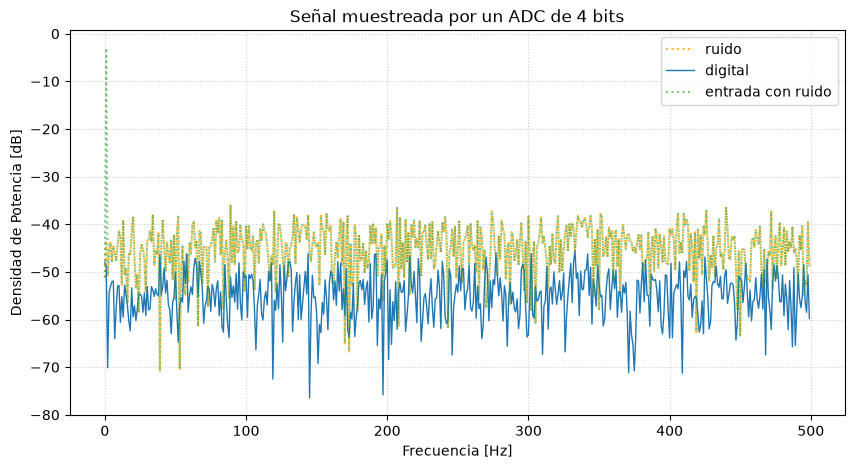

In [1]:
import numpy as np
import matplotlib.pyplot as plt

""""snr=20
pot_ruido=np.sqrt(10**(-snr/10))
"""

def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    xx=dc+vmax*np.sin(2*np.pi*ff*nn/fs+2*np.pi*ph)
    tt=nn/fs
    return(tt,xx)


fs = 1000 # Hz
N = 1000 # muestras
nn=np.arange(0,N)
# ff=250 la borré pero no sé dónde la estaba usando a esta altura
#Señal de entrada
pot_seno=1
vmax=np.sqrt(pot_seno*2) # (potencial máximo aka apmlitud máxima)
dc=0 # Valor medio (alrededor del que oscila)
df=fs/N #frecuencia de la señal
k=1 #bin
f_sen=k*df #frecuencia: ff=fs/N
ph=0

# ADC
B=4 # Bits
Vfs=2.0 # Volts
qq=(2*Vfs)/(2**B) # paso de cuantizacion
pq=qq**2/12 # Potencia teórica del ruido de cuantización

# Ruido analógico
kn=10
Pn=kn*pq # potencia del ruido
mu=0 #valor
pot_ruido=np.sqrt(Pn) #Desviación estándar que necesita la función para generar el ruido
snr=10*np.log10(pot_seno/Pn)

#Señal pura analógica
tt, xx= mi_funcion_sen(vmax, dc, f_sen, ph, nn, fs)
yy=np.random.normal(mu,pot_ruido,N)# ruido analógico
funcion_con_ruido=xx+yy

#Proceso de Cuantizacion
xx_q=np.round(funcion_con_ruido/qq)*qq
nq=xx_q-funcion_con_ruido # ruido por cuantizacion

#Eje de frecuencias hasta Nyquist

frec = np.fft.fftfreq(N, 1/fs)[:N//2] #Esto permite graficar en función de la frecuencia y no por los indices k

tr_pura=(1/N)*np.fft.fft(yy)[:N//2]
abs_pura_db=20*np.log10(np.abs(tr_pura))

tr_analogica=(1/N)*np.fft.fft(funcion_con_ruido)[:N//2]
abs_analogica_db=20*np.log10(np.abs(tr_analogica))

tr_digital=(1/N)*np.fft.fft(nq)[:N//2]
abs_digital_db=20*np.log10(np.abs(tr_digital))

# --- GRÁFICO DEL ESPECTRO (SIN PISOS) ---
plt.figure(figsize=(10, 5))

# Trazas de las señales
plt.plot(frec, abs_pura_db, ':', label='ruido', color='orange', alpha=0.8) #ruido de la analogica
plt.plot(frec, abs_digital_db, label='digital', color='tab:blue', linewidth=1) # ruido por cuantizacion
plt.plot(frec, abs_analogica_db, ':', label='entrada con ruido', color='tab:green', alpha=0.6) #señal con ruido

# Formato de la gráfica
plt.title(f"Señal muestreada por un ADC de {B} bits")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad de Potencia [dB]")
#plt.xlim(-10, fs/2 + 10)
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()